Dataset loaded successfully!
Shape of dataset: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...           

<Figure size 720x432 with 0 Axes>

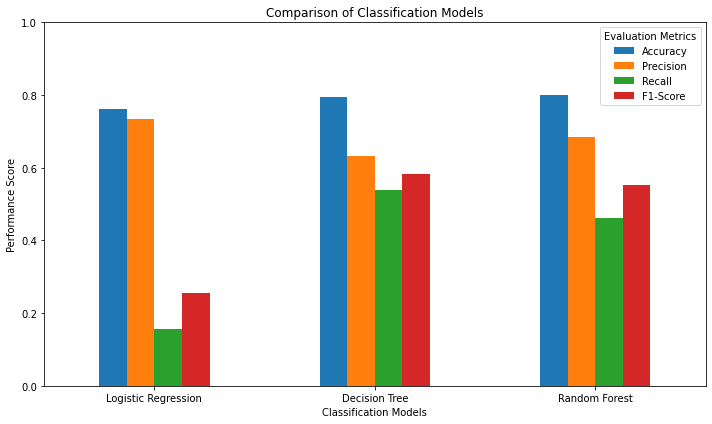


BEST PERFORMING MODEL
Best Model: Decision Tree
F1-Score: 0.5821

TOP 10 FACTORS INFLUENCING CHURN
tenure                            0.081452
MonthlyCharges                    0.058671
PaymentMethod_Electronic check    0.023708
Contract_Two year                 0.023430
InternetService_Fiber optic       0.022014
TechSupport_Yes                   0.018721
OnlineSecurity_Yes                0.018530
Contract_One year                 0.016192
PaperlessBilling_Yes              0.014005
OnlineBackup_Yes                  0.012886
dtype: float64


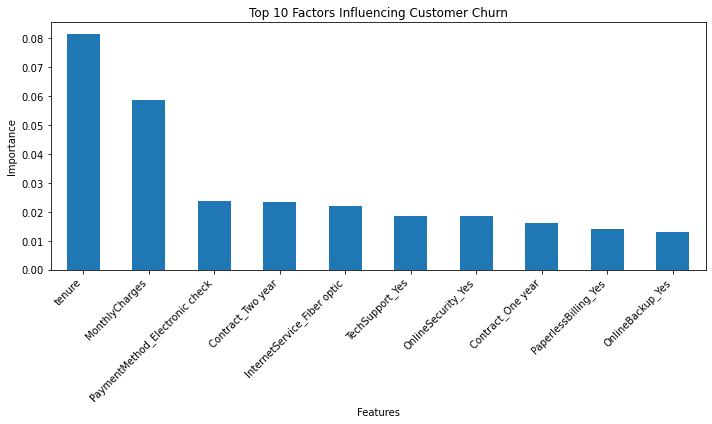


BUSINESS RECOMMENDATIONS

1. Target customers with low tenure:
   Provide special offers, onboarding support and loyalty
   benefits to new customers to reduce early churn.

2. Encourage long-term contracts:
   Provide discounts and additional benefits to customers
   who switch from short-term/month-to-month contracts
   to long-term plans.

3. Manage high monthly charges:
   Provide customized plans, discounts and suitable service
   packages for customers with high monthly charges.


EX3a COMPLETED SUCCESSFULLY


In [10]:
# ============================================================
# EX3a: MODEL PLANNING AND BUILDING - CLASSIFICATION
# Customer Churn Prediction
# ============================================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("Downloads\TelcoCustomer-Churn.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# 3. CHECK DATASET
# ============================================================

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())


# ============================================================
# 4. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop("Churn", axis=1)
y = df["Churn"]


# ============================================================
# 5. CONVERT TARGET VARIABLE TO NUMERICAL
# ============================================================

if y.dtype == "object":
    y = y.map({"Yes": 1, "No": 0})

print("\nTarget values:")
print(y.value_counts())


# ============================================================
# 6. CONVERT CATEGORICAL FEATURES TO NUMERICAL
# ============================================================

X = pd.get_dummies(X, drop_first=True)

print("\nFeatures after encoding:")
print(X.head())

print("\nNumber of features:", X.shape[1])


# ============================================================
# 7. TRAIN-TEST SPLIT
# 80% TRAINING AND 20% TESTING
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nData Split:")
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


# ============================================================
# 8. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================================
# 9. LOGISTIC REGRESSION
# ============================================================

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

y_pred_lr = logistic_model.predict(X_test_scaled)

print("\nLogistic Regression completed!")


# ============================================================
# 10. DECISION TREE CLASSIFIER
# ============================================================

decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)

print("Decision Tree completed!")


# ============================================================
# 11. RANDOM FOREST CLASSIFIER
# ============================================================

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

print("Random Forest completed!")


# ============================================================
# 12. EVALUATION FUNCTION
# ============================================================

def evaluate_model(y_test, y_pred, model_name):

    cm = confusion_matrix(y_test, y_pred)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("\n========================================")
    print(model_name)
    print("========================================")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nAccuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-Score :", round(f1, 4))

    return accuracy, precision, recall, f1


# ============================================================
# 13. EVALUATE LOGISTIC REGRESSION
# ============================================================

lr_results = evaluate_model(
    y_test,
    y_pred_lr,
    "LOGISTIC REGRESSION"
)


# ============================================================
# 14. EVALUATE DECISION TREE
# ============================================================

dt_results = evaluate_model(
    y_test,
    y_pred_dt,
    "DECISION TREE"
)


# ============================================================
# 15. EVALUATE RANDOM FOREST
# ============================================================

rf_results = evaluate_model(
    y_test,
    y_pred_rf,
    "RANDOM FOREST"
)


# ============================================================
# 16. CREATE MODEL COMPARISON TABLE
# ============================================================

results = pd.DataFrame(
    [lr_results, dt_results, rf_results],
    columns=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    index=[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ]
)

print("\n\n========================================")
print("MODEL PERFORMANCE COMPARISON")
print("========================================")

print(results.round(4))


# ============================================================
# 17. BAR CHART COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

results.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Classification Models")
plt.xlabel("Classification Models")
plt.ylabel("Performance Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Evaluation Metrics")
plt.tight_layout()

plt.show()


# ============================================================
# 18. IDENTIFY BEST MODEL
# ============================================================

best_model = results["F1-Score"].idxmax()
best_f1 = results["F1-Score"].max()

print("\n========================================")
print("BEST PERFORMING MODEL")
print("========================================")

print("Best Model:", best_model)
print("F1-Score:", round(best_f1, 4))


# ============================================================
# 19. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.Series(
    random_forest.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

print("\n========================================")
print("TOP 10 FACTORS INFLUENCING CHURN")
print("========================================")

print(feature_importance.head(10))


# ============================================================
# 20. FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

feature_importance.head(10).plot(kind="bar")

plt.title("Top 10 Factors Influencing Customer Churn")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()


# ============================================================
# 21. BUSINESS RECOMMENDATIONS
# ============================================================

print("\n========================================")
print("BUSINESS RECOMMENDATIONS")
print("========================================")

print("""
1. Target customers with low tenure:
   Provide special offers, onboarding support and loyalty
   benefits to new customers to reduce early churn.

2. Encourage long-term contracts:
   Provide discounts and additional benefits to customers
   who switch from short-term/month-to-month contracts
   to long-term plans.

3. Manage high monthly charges:
   Provide customized plans, discounts and suitable service
   packages for customers with high monthly charges.
""")

print("\n========================================")
print("EX3a COMPLETED SUCCESSFULLY")
print("========================================")